# From-scratch pretraining: reading the results

Every finished run in `runs/`, grouped by the experiment it belongs to. Five experiments live
here now and they answer different questions, so nothing below mixes them on one axis.

| experiment | question |
|---|---|
| **Yoruba grid** | Does more data or more compute move the loss, at the POC's budgets? |
| **Five languages** | At matched data and compute, how much does the language matter? |
| **English ladder** | With compute fixed, does more text keep helping — and does the bigger model catch up? |
| **Yoruba rungs** | Does the English saturation threshold transfer? |

Run it after any fleet finishes; it reads `runs/*_result.json` and re-renders.

In [1]:
import json, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import mlm_api as factory

# The validated categorical palette, used in fixed slot order. Blue is always the first series,
# orange the second -- colour follows the entity, so a filter that drops a series never repaints
# the survivors. Text stays in ink colours; a coloured mark beside a label carries the identity.
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID = "#e6e5e1"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    # axisbelow keeps the grid behind the marks. Without it matplotlib draws gridlines over the
    # bars, which puts a recessive element on top of the data it is meant to sit behind.
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "lines.linewidth": 2.0, "lines.markersize": 8,
})

# Five languages needs five colours, and the old three-slot palette silently reused blue for
# rungs four and five. Extending it keeps the rule -- colour follows the entity -- rather than
# abandoning it.
C4, C5 = "#8b5cf6", "#d4a017"
SLOTS = [C1, C2, C3, C4, C5]

PRESET_SIZE = {"poc": "33.8M", "afriberta": "86M"}


def experiment_of(tag, corpus):
    """Which experiment a run belongs to. Charts scope to one; none of them mix.

    Keyed on the corpus and the compute budget rather than on the tag's shape, because the
    Yoruba saturation rungs share the grid's naming and would otherwise land in the grid's
    charts -- which is exactly how the compute axis quietly grew from three budgets to seven.
    """
    if corpus is None:
        return "scratch"        # batchtest / lrprobe / stabcheck -- probes, not study cells
    if tag.startswith("multi_"):
        return "five languages"
    if corpus == "eng_1b":
        return "english ladder"
    if corpus == "yor":
        return "yoruba rungs" if "_62.5k_" in tag else "yoruba grid"
    return corpus


def unigram_h(corpus):
    """The loss from predicting token frequencies and ignoring context.

    Subtracting it is what makes two languages comparable: each corpus has its own 16k
    vocabulary, so raw loss on Yoruba and raw loss on English are not measurements of the same
    quantity. Written by the dashboard; absent until something has asked for it.
    """
    if not corpus:
        return None
    try:
        with open(os.path.join("data", corpus, "unigram_entropy.json"), encoding="utf-8") as f:
            return json.load(f)["entropy"]
    except (OSError, ValueError, KeyError):
        return None



# The significance threshold, measured rather than remembered. This started as SEED_SD = 0.049,
# a number taken from the 33.8M model on Yoruba at 196.6M updates, and then used to judge every
# other model, corpus and budget in the project. Re-seeding showed it is 0.134 for 33.8M English
# at 1.024B updates and 1.327 for the 86M preset -- so it is a property of the cell, not a
# constant, and hard-coding one value silently mis-scaled every comparison drawn against it.
def seed_spread(frame, fallback=0.15):
    """Pooled within-cell standard deviation over every cell that has more than one seed.

    Falls back only when nothing in the frame has been repeated, and says so, because an
    unmeasured threshold that looks measured is what caused the problem this replaces.
    """
    sds, cells = [], 0
    for _, g in frame.groupby(["corpus", "preset", "n_tokens", "steps"]):
        if len(g) > 1:
            sds.append(g["val_loss"].std(ddof=1))
            cells += 1
    if not sds:
        return fallback, 0
    return sum(sds) / len(sds), cells

all_rows = factory.results("*")
for r in all_rows:
    r["preset"] = r.get("preset") or "poc"
    r["size"] = PRESET_SIZE.get(r["preset"], r["preset"])
    r["update_tokens"] = r["steps"] * r["batch"] * r["seq_len"]
    r["experiment"] = experiment_of(r["tag"], r.get("corpus"))
    r["unigram_h"] = unigram_h(r.get("corpus"))
    # What the model learned FROM CONTEXT, with the vocabulary's own entropy cancelled out.
    r["gained"] = (r["unigram_h"] - r["val_loss"]) if r["unigram_h"] else None

if not all_rows:
    print("No completed runs yet. Train something first:\n"
          "    python mlm_fleet.py --corpus yor --queue poc")
else:
    from collections import Counter
    print(f"{len(all_rows)} completed runs\n")
    for exp, n in sorted(Counter(r["experiment"] for r in all_rows).items()):
        print(f"  {exp:18s} {n:3d} runs")

60 completed runs

  english ladder      22 runs
  five languages       5 runs
  scratch              8 runs
  yoruba grid         20 runs
  yoruba rungs         5 runs


## The results table

The table view is the accessible companion to every chart below: the same numbers, exactly,
without relying on colour or position to read them.

`random_loss` is `log(vocab_size)` -- the loss of a model that has learned nothing about the
language and predicts uniformly. A val loss near it means the run has not started learning.


In [2]:
import pandas as pd

df = pd.DataFrame(all_rows) if all_rows else pd.DataFrame()
if not df.empty:
    view = df[["experiment", "tag", "corpus", "size", "n_tokens", "steps", "update_tokens",
               "passes", "val_loss", "gained", "seconds", "tokens_per_s"]].copy()
    view = view.sort_values(["experiment", "corpus", "n_tokens", "update_tokens"])
    view = view.reset_index(drop=True)
    display(view.style.format({
        "n_tokens": "{:,.0f}", "steps": "{:,.0f}", "update_tokens": "{:,.0f}",
        "passes": "{:.1f}", "val_loss": "{:.3f}", "gained": "{:.3f}",
        "seconds": "{:.0f}", "tokens_per_s": "{:,.0f}"}, na_rep="-"))

,experiment,tag,corpus,size,n_tokens,steps,update_tokens,passes,val_loss,gained,seconds,tokens_per_s
0,english ladder,eng_1b_4M_62.5k_afriberta_s0,eng_1b,86M,"4,000,000","62,500","1,024,000,000",256.0,6.720,0.772,5482,"186,791"
1,english ladder,eng_1b_4M_62.5k_s0,eng_1b,33.8M,"4,000,000","62,500","1,024,000,000",256.0,3.284,4.208,3063,"334,354"
2,english ladder,eng_1b_16M_62.5k_afriberta_s0,eng_1b,86M,"16,000,000","62,500","1,024,000,000",64.0,3.200,4.291,5561,"184,152"
3,english ladder,eng_1b_16M_62.5k_afriberta_s1,eng_1b,86M,"16,000,000","62,500","1,024,000,000",64.0,3.760,3.731,5685,"180,115"
4,english ladder,eng_1b_16M_62.5k_afriberta_s2,eng_1b,86M,"16,000,000","62,500","1,024,000,000",64.0,5.661,1.831,5511,"185,804"
5,english ladder,eng_1b_16M_62.5k_s0,eng_1b,33.8M,"16,000,000","62,500","1,024,000,000",64.0,2.361,5.130,2439,"419,927"
6,english ladder,eng_1b_16M_62.5k_s1,eng_1b,33.8M,"16,000,000","62,500","1,024,000,000",64.0,2.554,4.937,4843,"211,426"
7,english ladder,eng_1b_16M_62.5k_s2,eng_1b,33.8M,"16,000,000","62,500","1,024,000,000",64.0,2.718,4.773,4951,"206,824"
8,english ladder,eng_1b_64M_62.5k_afriberta_s0,eng_1b,86M,"64,000,000","62,500","1,024,000,000",16.0,3.278,4.213,5502,"186,125"
9,english ladder,eng_1b_64M_62.5k_afriberta_s1,eng_1b,86M,"64,000,000","62,500","1,024,000,000",16.0,2.818,4.673,5506,"185,989"


## 1. The Yoruba grid: which axis binds?

The POC's original question. **Scoped to the 33.8M model and to this experiment's own budgets** —
without that scope the chart mixes in the 86M runs at the same rungs (which land two nats higher)
and the 1.024B-update saturation rungs, and reads as noise.

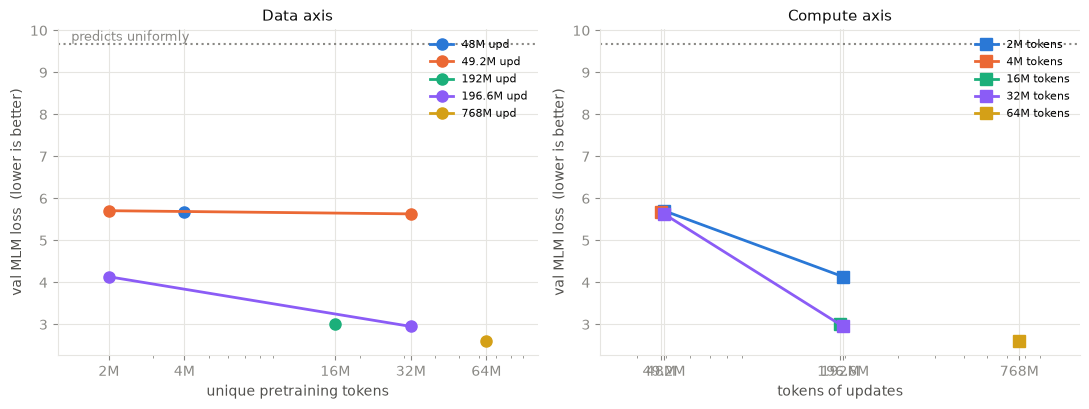

13 runs, 33.8M model only
at 49.2M updates, varying data over 2 rungs moves val loss by 0.076
at 2M tokens, varying compute over 2 budgets moves val loss by 1.572
-> compute-bound


In [3]:
grid = df[(df["experiment"] == "yoruba grid") & (df["preset"] == "poc")].copy()
if not grid.empty:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    toks_seen = sorted(grid["n_tokens"].unique())
    steps_seen = sorted(grid["update_tokens"].unique())
    fmt = factory.compact

    # Every budget gets a slot. The old version took the first three of however many existed,
    # which dropped runs from the picture without saying so.
    for i, s in enumerate(steps_seen):
        sub = grid[grid["update_tokens"] == s].groupby("n_tokens", as_index=False)["val_loss"]\
                  .mean().sort_values("n_tokens")
        if len(sub):
            ax[0].plot(sub["n_tokens"], sub["val_loss"], "o-",
                       color=SLOTS[i % len(SLOTS)], label=f"{fmt(s)} upd")
    for i, n in enumerate(toks_seen):
        sub = grid[grid["n_tokens"] == n].groupby("update_tokens", as_index=False)["val_loss"]\
                  .mean().sort_values("update_tokens")
        if len(sub):
            ax[1].plot(sub["update_tokens"], sub["val_loss"], "s-",
                       color=SLOTS[i % len(SLOTS)], label=f"{fmt(n)} tokens")

    rl = float(grid["random_loss"].dropna().iloc[0]) if grid["random_loss"].notna().any() else None
    for a in ax:
        if rl:
            a.axhline(rl, ls=":", lw=1.5, color=MUTED)
        a.set_ylabel("val MLM loss  (lower is better)")
        a.legend(loc="upper right", fontsize=8)
    if rl:
        ax[0].text(0.02, rl, " predicts uniformly", transform=ax[0].get_yaxis_transform(),
                   va="bottom", ha="left", color=MUTED, fontsize=9)

    ax[0].set_xlabel("unique pretraining tokens"); ax[0].set_title("Data axis")
    ax[1].set_xlabel("tokens of updates"); ax[1].set_title("Compute axis")
    for a, vals in ((ax[0], toks_seen), (ax[1], steps_seen)):
        a.set_xscale("log"); a.set_xticks(vals)
        a.set_xticklabels([fmt(v) for v in vals])
        a.xaxis.set_minor_formatter(mticker.NullFormatter())
        a.set_xlim(min(vals) / 1.6, max(vals) * 1.6)
    fig.tight_layout(); plt.show()

    # Read the verdict off a slice that actually VARIES. The grid is ragged -- its largest
    # compute budget was only ever run at one data rung, and its largest data rung at one budget
    # -- so taking the largest of each gives a range of zero on both axes, and "0 > 2*0" is
    # False, which printed "data matters at least as much as compute". Structurally guaranteed
    # to be wrong, and it survived because the grid used to be square enough to hide it.
    def widest(fixed, varied):
        best, n_best = None, 1
        for v in sorted(grid[fixed].unique()):
            sub = grid[grid[fixed] == v]
            if sub[varied].nunique() > n_best:
                best, n_best = v, sub[varied].nunique()
        return best

    b_slice = widest("update_tokens", "n_tokens")
    n_slice = widest("n_tokens", "update_tokens")
    print(f"{len(grid)} runs, 33.8M model only")
    if b_slice is None or n_slice is None:
        print("not enough cells vary on both axes to compare them here")
    else:
        d = grid[grid["update_tokens"] == b_slice].groupby("n_tokens")["val_loss"].mean()
        c = grid[grid["n_tokens"] == n_slice].groupby("update_tokens")["val_loss"].mean()
        rng_data, rng_comp = d.max() - d.min(), c.max() - c.min()
        print(f"at {factory.compact(b_slice)} updates, varying data over "
              f"{len(d)} rungs moves val loss by {rng_data:.3f}")
        print(f"at {factory.compact(n_slice)} tokens, varying compute over "
              f"{len(c)} budgets moves val loss by {rng_comp:.3f}")
        print("-> compute-bound" if rng_comp > 2 * rng_data else
              "-> data matters at least as much as compute here")


### The phase transition

Both models start near the unigram entropy and sit there. The interesting event is the *breakout* —
where the loss falls away from the plateau, which is where the model stops guessing frequencies
and starts using context. Dashed lines are the 86M model.

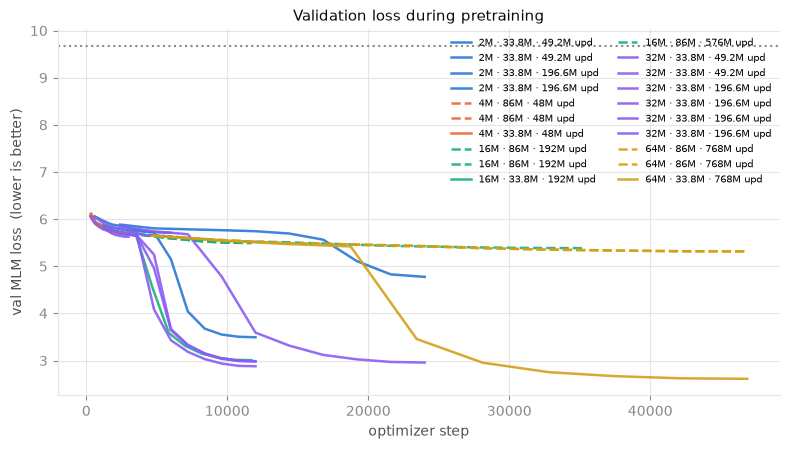

In [4]:
curves = df[df["experiment"] == "yoruba grid"]
if not curves.empty:
    fig, ax = plt.subplots(figsize=(8, 4.6))
    toks = sorted(curves["n_tokens"].unique())
    colors = {n: SLOTS[i % len(SLOTS)] for i, n in enumerate(toks)}

    for _, r in curves.sort_values(["n_tokens", "update_tokens"]).iterrows():
        h = factory.curve(r["tag"])
        if not h:
            continue
        # Model size is the line style, not another colour -- colour is spent on the data rung.
        # Drawn as one series per run rather than one per rung, because the 86M and 33.8M runs
        # at the same rung are different experiments and used to be joined into one line.
        ax.plot([p["step"] for p in h], [p["val"]["loss"] for p in h],
                "--" if r["preset"] == "afriberta" else "-",
                color=colors[r["n_tokens"]], lw=1.8, alpha=0.9,
                label=f'{factory.compact(r["n_tokens"])} · {r["size"]} · '
                      f'{factory.compact(r["update_tokens"])} upd')

    rl = curves["random_loss"].dropna()
    if len(rl):
        ax.axhline(float(rl.iloc[0]), ls=":", lw=1.5, color=MUTED)
    ax.set_xlabel("optimizer step"); ax.set_ylabel("val MLM loss  (lower is better)")
    ax.set_title("Validation loss during pretraining")
    ax.legend(loc="upper right", ncols=2, fontsize=7)
    fig.tight_layout(); plt.show()

## 2. Five languages, matched budget

Same 33.8M model, same 50M tokens of data, same 196.6M tokens of updates. Only the language
differs.

**Raw validation loss does not compare across these.** Each corpus has its own 16k BPE with its
own frequency distribution, so a loss of 2.9 on Yoruba and 3.6 on English are not measurements of
the same quantity — most of that gap is the vocabulary. Subtracting each corpus's unigram entropy
leaves what the model learned *from context*, which does compare. Both are plotted so the
difference between them is visible rather than asserted.

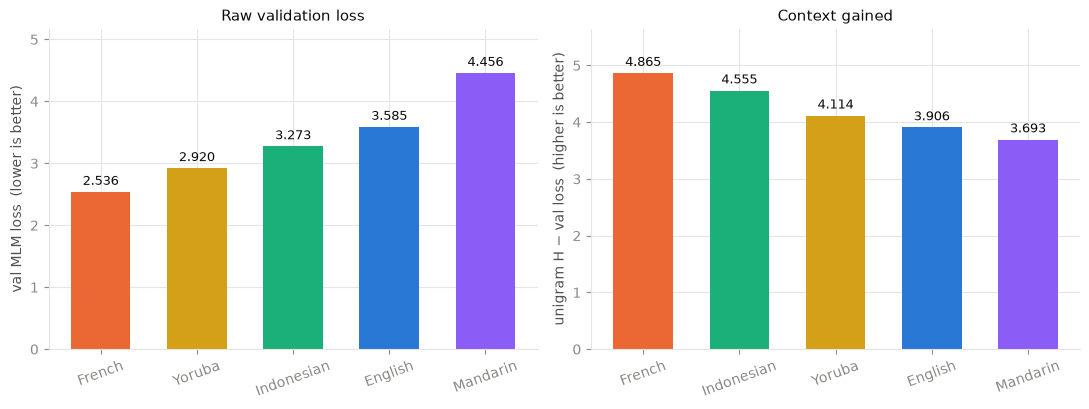

Yoruba gains 4.114 nats of context; English 3.906.
At matched data and compute, nothing about Yoruba resists modelling.

Caveat: matching on tokens is not matching on text. Mandarin read ~72M characters where
Indonesian read ~233M, so its last place is largely a units artifact.


In [5]:
langs = df[df["experiment"] == "five languages"].copy()
NAMES = {"eng": "English", "fra": "French", "ind": "Indonesian",
         "cmn": "Mandarin", "yor": "Yoruba"}
if not langs.empty:
    langs["language"] = langs["corpus"].map(lambda c: NAMES.get(c, c))
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

    raw = langs.sort_values("val_loss")
    gain = langs.sort_values("gained", ascending=False)
    # Yoruba keeps its colour in both panels even though its rank changes -- that is the point
    # of the pair, and repainting by position would hide it.
    hue = {l: SLOTS[i % len(SLOTS)] for i, l in enumerate(sorted(langs["language"]))}

    for a, sub, col, title, note in (
            (ax[0], raw, "val_loss", "Raw validation loss", "not comparable across languages"),
            (ax[1], gain, "gained", "Context gained", "vocabulary entropy removed")):
        bars = a.bar(sub["language"], sub[col], color=[hue[l] for l in sub["language"]], width=.62)
        a.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, color=INK)
        a.set_title(title); a.set_ylabel(note)
        a.tick_params(axis="x", rotation=20)
        a.margins(y=.16)
    ax[0].set_ylabel("val MLM loss  (lower is better)")
    ax[1].set_ylabel("unigram H − val loss  (higher is better)")
    fig.tight_layout(); plt.show()

    y = langs[langs["corpus"] == "yor"]
    e = langs[langs["corpus"] == "eng"]
    if len(y) and len(e):
        print(f'Yoruba gains {float(y["gained"].iloc[0]):.3f} nats of context; '
              f'English {float(e["gained"].iloc[0]):.3f}.')
        print("At matched data and compute, nothing about Yoruba resists modelling.")
    print("\nCaveat: matching on tokens is not matching on text. Mandarin read ~72M characters "
          "where\nIndonesian read ~233M, so its last place is largely a units artifact.")

## 3. The English ladder: where does data stop helping?

Five data rungs spanning **256×**, with compute held fixed at 1.024B tokens of updates at every
rung. Fixed is the point — scaling compute alongside data would confound the two axes.

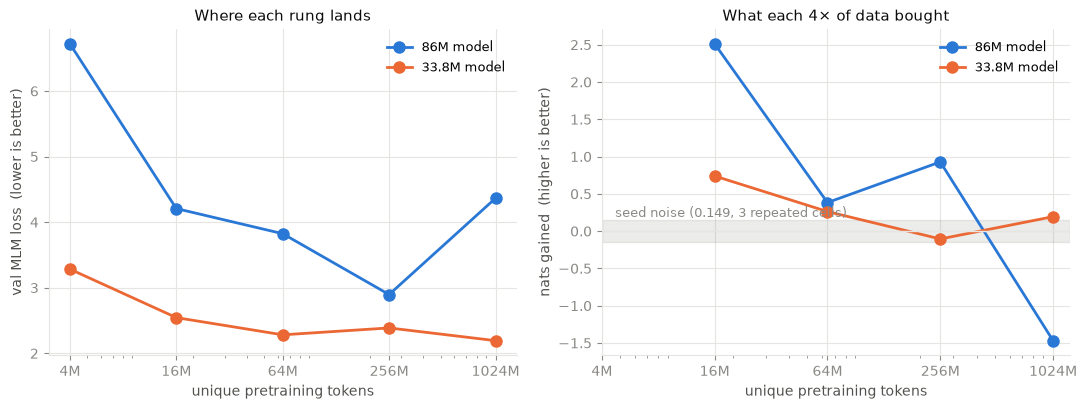

33.8M model, seed spread 0.149 over 3 repeated cells

              step     gain  x spread    seeds  reading
      4M->    16M   +0.739     4.96x      1/3  real
     16M->    64M   +0.263     1.76x      3/3  cannot resolve
     64M->   256M   -0.105     0.70x      3/3  noise
    256M->  1024M   +0.194     1.30x      3/1  cannot resolve


In [6]:
lad = df[df["experiment"] == "english ladder"].copy()
if not lad.empty:
    cell = lad.groupby(["preset", "size", "n_tokens"], as_index=False)["val_loss"].mean()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

    for i, (preset, sub) in enumerate(cell.groupby("preset")):
        sub = sub.sort_values("n_tokens")
        ax[0].plot(sub["n_tokens"], sub["val_loss"], "o-", color=SLOTS[i],
                   label=f'{sub["size"].iloc[0]} model')
        # Marginal gain per 4x of data: the derivative is what says "stopped helping", and
        # reading it off the curve by eye is exactly where the first draft of the report went
        # wrong.
        d = sub["val_loss"].values
        xs = sub["n_tokens"].values[1:]
        ax[1].plot(xs, d[:-1] - d[1:], "o-", color=SLOTS[i],
                   label=f'{sub["size"].iloc[0]} model')

    SEED_SD, n_cells = seed_spread(lad[lad["preset"] == "poc"])
    ax[1].axhspan(-SEED_SD, SEED_SD, color=MUTED, alpha=.16)
    ax[1].text(0.02, SEED_SD,
               f" seed noise ({SEED_SD:.3f}"
               + (f", {n_cells} repeated cells)" if n_cells else ", ASSUMED)"),
               transform=ax[1].get_yaxis_transform(), va="bottom", color=MUTED, fontsize=9)
    ax[1].axhline(0, color=GRID, lw=1)

    ax[0].set_title("Where each rung lands"); ax[0].set_ylabel("val MLM loss  (lower is better)")
    ax[1].set_title("What each 4× of data bought")
    ax[1].set_ylabel("nats gained  (higher is better)")
    for a in ax:
        a.set_xscale("log"); a.set_xlabel("unique pretraining tokens")
        a.set_xticks(sorted(cell["n_tokens"].unique()))
        a.set_xticklabels([factory.compact(v) for v in sorted(cell["n_tokens"].unique())])
        a.xaxis.set_minor_formatter(mticker.NullFormatter())
        a.legend(loc="best", fontsize=9)
    fig.tight_layout(); plt.show()

    small = cell[cell["preset"] == "poc"].sort_values("n_tokens")
    seeds = (lad[lad["preset"] == "poc"].groupby("n_tokens")["val_loss"].count())
    if len(small) > 2:
        d, ns = small["val_loss"].values, small["n_tokens"].values
        print(f"33.8M model, seed spread {SEED_SD:.3f} over {n_cells} repeated cells\n")
        print(f'{"step":>18s}{"gain":>9s}{"x spread":>10s}  {"seeds":>7s}  reading')
        for i in range(len(d) - 1):
            gain = d[i] - d[i + 1]
            ratio = abs(gain) / SEED_SD
            # Three bands, not two. A step smaller than the spread is noise; one larger than
            # twice it is real; in between the honest answer is that this many seeds cannot say,
            # and collapsing that middle band into either neighbour is how a single lucky draw
            # became a reported finding.
            reading = "real" if ratio > 2 else ("cannot resolve" if ratio > 1 else "noise")
            n_seed = f'{seeds.get(ns[i], 1)}/{seeds.get(ns[i + 1], 1)}'
            print(f'{factory.compact(int(ns[i])):>8}->{factory.compact(int(ns[i+1])):>7}'
                  f'{gain:+9.3f}{ratio:9.2f}x  {n_seed:>7}  {reading}')

## 4. Does the threshold transfer to Yoruba?

All of FineWeb-2 Yoruba is 69.1M tokens, so the English ladder's top rungs cannot be run in it.
What *can* be checked is whether the two languages decelerate on the same schedule over the rungs
they share.

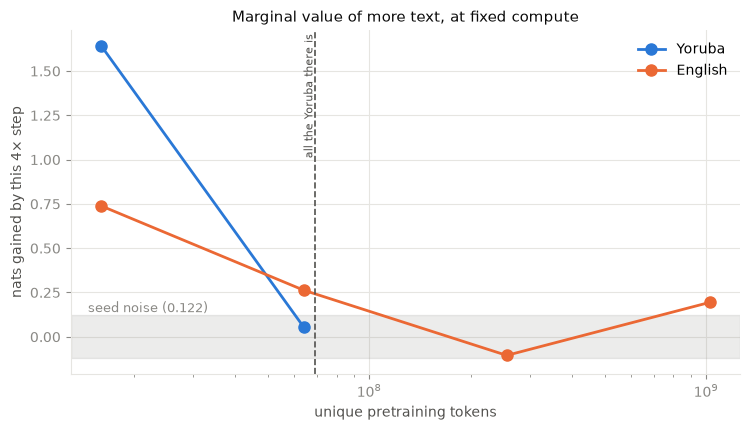

at   16M: Yoruba +1.644, English +0.739, apart by 0.905
at   64M: Yoruba +0.053, English +0.263, apart by 0.209

Seed spread 0.122, pooled over 5 repeated cells. Two languages agreeing to
within that decelerate alike -- but so would two that differ by less than we can measure,
so this is consistency, not proof.


In [7]:
yr = df[(df["experiment"] == "yoruba rungs") & (df["preset"] == "poc")]
en = df[(df["experiment"] == "english ladder") & (df["preset"] == "poc")]
if not yr.empty and not en.empty:
    def marginal(sub):
        s = sub.groupby("n_tokens", as_index=False)["val_loss"].mean().sort_values("n_tokens")
        v, n = s["val_loss"].values, s["n_tokens"].values
        return n[1:], v[:-1] - v[1:]

    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    for (name, sub, colour) in (("Yoruba", yr, C1), ("English", en, C2)):
        xs, gains = marginal(sub)
        ax.plot(xs, gains, "o-", color=colour, label=name)

    # Both languages pooled: the question is whether their CURVES differ, so the band has to
    # describe the noise in both.
    SEED_SD, n_cells = seed_spread(df[(df["preset"] == "poc")
                                      & df["corpus"].isin(["yor", "eng_1b"])])
    ax.axhspan(-SEED_SD, SEED_SD, color=MUTED, alpha=.16)
    ax.text(0.02, SEED_SD, f" seed noise ({SEED_SD:.3f})",
            transform=ax.get_yaxis_transform(), va="bottom", color=MUTED, fontsize=9)

    # Where Yoruba simply stops existing. The chart should show the wall, not end quietly.
    ax.axvline(69_096_452, color=INK2, ls="--", lw=1.2)
    ax.text(69_096_452, ax.get_ylim()[1], " all the Yoruba there is ", rotation=90,
            va="top", ha="right", color=INK2, fontsize=8)

    ax.set_xscale("log"); ax.set_xlabel("unique pretraining tokens")
    ax.set_ylabel("nats gained by this 4× step")
    ax.set_title("Marginal value of more text, at fixed compute")
    ax.legend(loc="best")
    fig.tight_layout(); plt.show()

    xs_y, g_y = marginal(yr)
    xs_e, g_e = marginal(en)
    shared = [(x, gy, ge) for x, gy in zip(xs_y, g_y) for xe, ge in zip(xs_e, g_e) if xe == x]
    for x, gy, ge in shared:
        print(f"at {factory.compact(int(x)):>5}: Yoruba {gy:+.3f}, English {ge:+.3f}, "
              f"apart by {abs(gy - ge):.3f}")
    print(f"\nSeed spread {SEED_SD:.3f}, pooled over {n_cells} repeated cells. Two languages "
          f"agreeing to\nwithin that decelerate alike -- but so would two that differ by less "
          f"than we can measure,\nso this is consistency, not proof.")

## 5. What the runs cost

`tokens_per_s` is measured, not modelled — and it is now measured **per model size**, so the
projection no longer needs the `hidden² × depth` rule the POC used. The two presets differ by
more than a factor of two, so a median across both describes neither.

These are **GPU-hours**. Run through `mlm_fleet.py` on both cards and elapsed time is roughly
half of them.

In [8]:
if not df.empty:
    rate = (df.groupby(["preset", "size"])
              .apply(lambda g: (g["update_tokens"].sum() / g["seconds"].sum()),
                     include_groups=False)
              .rename("tok_s").reset_index())
    display(rate.style.format({"tok_s": "{:,.0f}"}))

    # Aggregate tokens over aggregate seconds, not the mean of per-run rates: a two-minute smoke
    # cell and a ninety-minute cell should not get equal weight in a throughput number.
    rates = dict(zip(rate["preset"], rate["tok_s"]))
    for preset, size in (("poc", "33.8M"), ("afriberta", "86M")):
        if preset in rates:
            print(f"{size:>6} model: {rates[preset]/1e3:5.0f}k tokens of updates/sec  (measured)")
    if len(rates) == 2:
        print(f"\n  the 86M model costs {rates['poc']/rates['afriberta']:.2f}x per token")

    print(f'\n{"study":>26}{"cells":>7}{"upd tokens":>14}{"GPU-h":>8}{"2-card h":>10}')
    for exp, g in df.groupby("experiment"):
        gpu_h = sum(r["update_tokens"] / rates.get(r["preset"], rates.get("poc", 4e5)) / 3600
                    for _, r in g.iterrows())
        print(f'{exp:>26}{len(g):>7}{g["update_tokens"].sum():>16,}'
              f'{gpu_h:>8.1f}{gpu_h/2:>10.1f}')

    total_h = df["seconds"].sum() / 3600
    print(f'\n{"actually spent":>26}{len(df):>7}{df["update_tokens"].sum():>16,}'
          f'{total_h:>8.1f}{"":>10}')

,preset,size,tok_s
0,afriberta,86M,"174,446"
1,poc,33.8M,"373,083"


 33.8M model:   373k tokens of updates/sec  (measured)
   86M model:   174k tokens of updates/sec  (measured)

  the 86M model costs 2.14x per token

                     study  cells    upd tokens   GPU-h  2-card h
            english ladder     22  22,528,000,000    26.3      13.2
            five languages      5     983,040,000     0.7       0.4
                   scratch      8   1,545,240,576     2.5       1.2
               yoruba grid     20   4,976,279,552     5.9       3.0
              yoruba rungs      5   5,120,000,000     3.8       1.9

            actually spent     60  35,152,560,128    39.2          


## 6. What the wider token store costs

int16 versus int32 for the resident token stream, measured rather than assumed. A 16k vocabulary
fits in int16; a shared multilingual vocabulary of 250k does not.

,width,bytes/token,store GB,peak GB,step tok/s
0,int16,2,0.248,9.070,"772,664"
1,int32,4,0.495,9.316,"773,705"


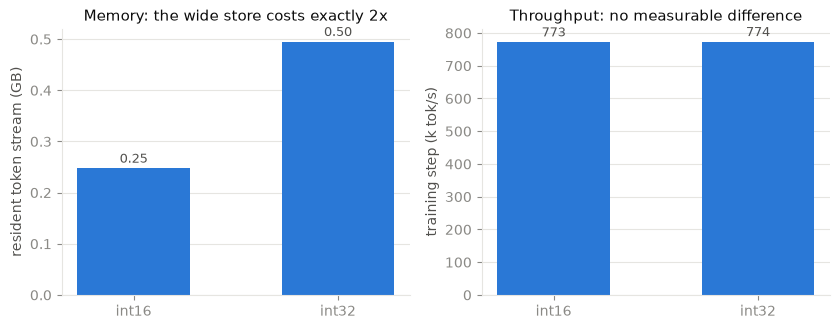

In [9]:
bench_path = "store_bench_gpt.json"
if os.path.exists(bench_path):
    with open(bench_path, encoding="utf-8") as f:
        b = json.load(f)
    br = {r["store_dtype"]: r for r in b["rows"]}

    tbl = pd.DataFrame([{
        "width": k,
        "bytes/token": v["bytes_per_token"],
        "store GB": v["store_bytes"] / 1e9,
        "peak GB": v["peak_bytes"] / 1e9,
        "step tok/s": v["step_tok_s"],
    } for k, v in br.items()])
    display(tbl.style.format({"store GB": "{:.3f}", "peak GB": "{:.3f}",
                              "step tok/s": "{:,.0f}"}))

    fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
    names = list(br)
    # Magnitude against a categorical axis: one hue, identity read off the axis labels, so no
    # legend is needed and none is drawn.
    ax[0].bar(names, [br[k]["store_bytes"] / 1e9 for k in names], color=C1, width=0.55)
    ax[0].set_ylabel("resident token stream (GB)")
    ax[0].set_title("Memory: the wide store costs exactly 2x")
    ax[1].bar(names, [br[k]["step_tok_s"] / 1e3 for k in names], color=C1, width=0.55)
    ax[1].set_ylabel("training step (k tok/s)")
    ax[1].set_title("Throughput: no measurable difference")
    for a in ax:
        a.grid(axis="x", visible=False)
    for a, vals in ((ax[0], [br[k]["store_bytes"] / 1e9 for k in names]),
                    (ax[1], [br[k]["step_tok_s"] / 1e3 for k in names])):
        for x, v in zip(names, vals):
            a.annotate(f"{v:,.2f}" if v < 10 else f"{v:,.0f}", (x, v),
                       textcoords="offset points", xytext=(0, 4),
                       ha="center", color=INK2, fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print(f"{bench_path} not found -- run store_bench.py with --json to generate it.")


## 7. Reading this run

1. **Which axis binds.** If the compute panel moves and the data panel does not, the ladder in
   the proposal cannot answer its question at this budget. Say so, and report it -- a measured
   "we were compute-bound" is a finding, not a failure.
2. **The random-init control.** It is not in this notebook, because it is a fine-tuning result,
   not a pretraining one. It stays in the POC notebook where the SIB-200 harness lives. Whatever
   the pretrained cells score above it is what pretraining bought; a gain inside the seed spread
   is not a gain.
3. **Seeds.** Everything above is one seed unless the grid was run with more. Before quoting any
   gap, run `python mlm_fleet.py --corpus yor --queue seeds` and check the spread is smaller than
   the effect.